Connnect with Goole Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'titanic' in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/Colab Notebooks/Lab_2_Linear_and_Logistic_Regression/titanic.csv


Load the dataset

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Lab_2_Linear_and_Logistic_Regression/titanic.csv')  # adjust path if needed

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Data Exploration Graph**

In [ ]:
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (891, 12)

Column Names:
 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Plot

/tmp/ipykernel_2991/247548188.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


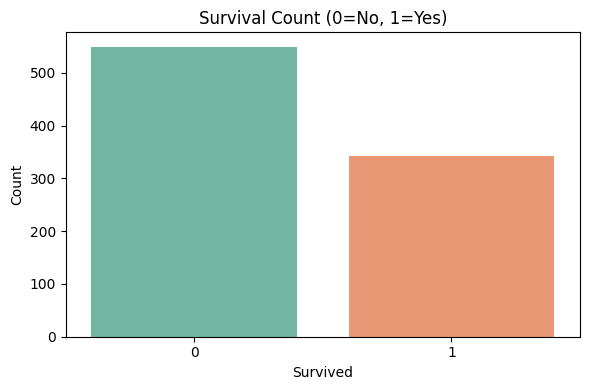

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Survival Count (0=No, 1=Yes)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Suri

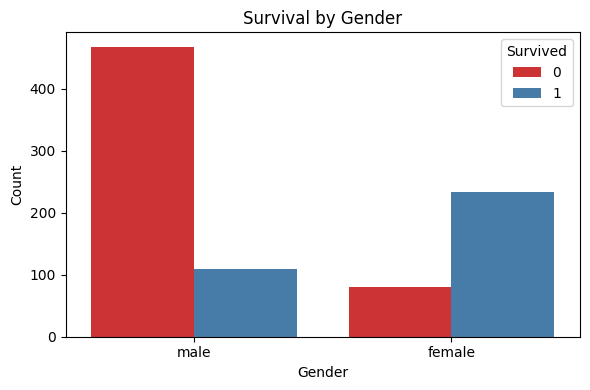

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set1')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

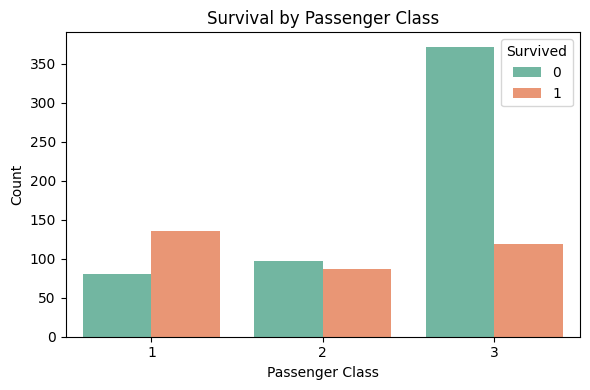

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

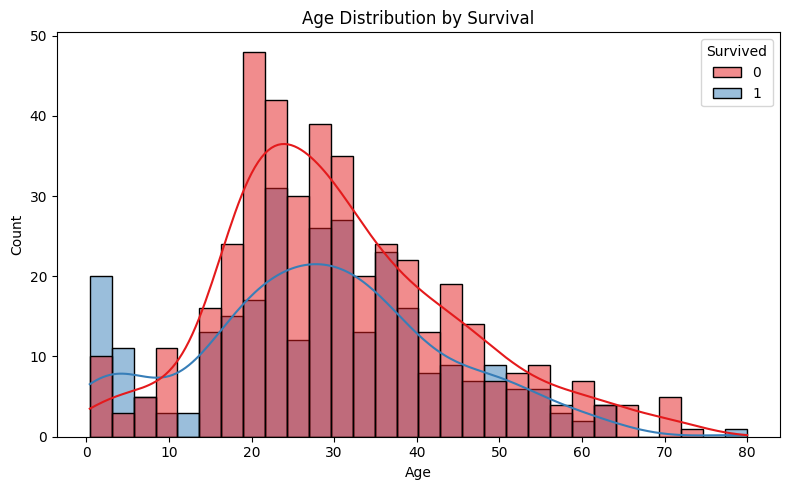

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, palette='Set1', bins=30)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2991/443326896.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, palette='Set2')


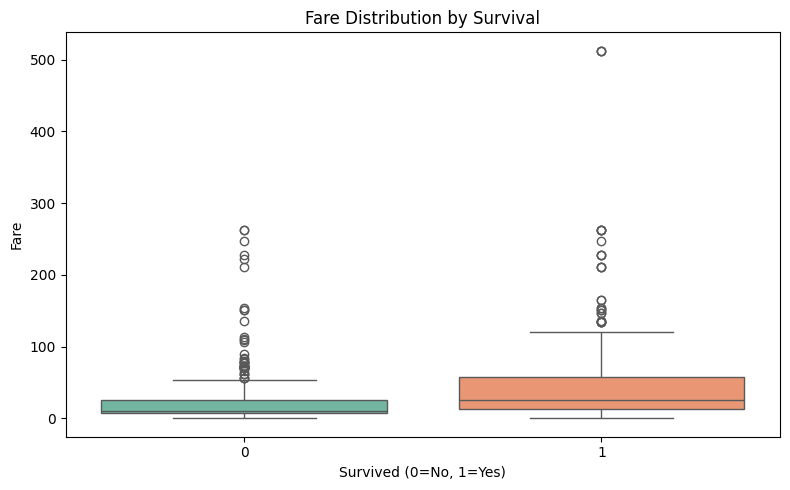

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Fare', data=df, palette='Set2')
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Fare')
plt.tight_layout()
plt.show()

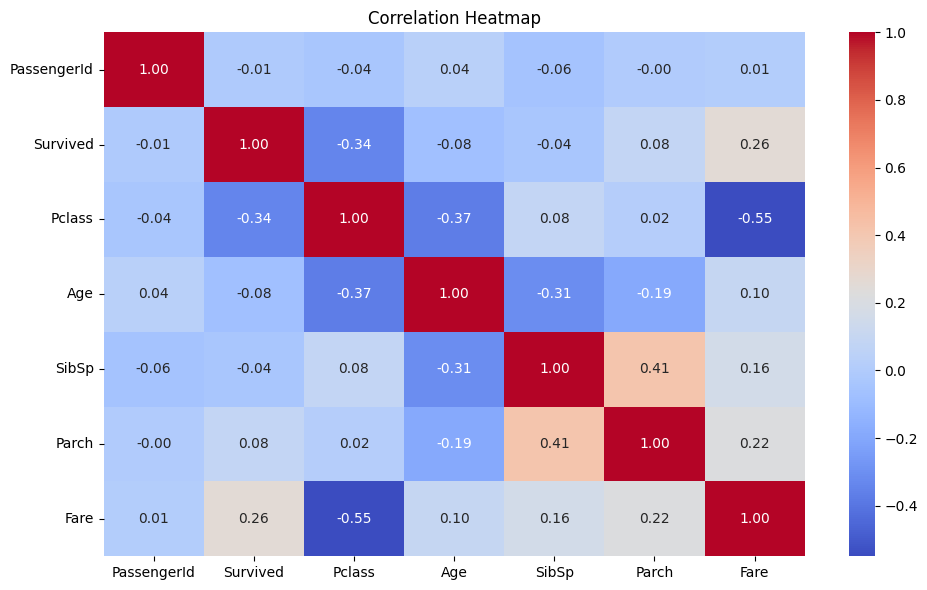

In [ ]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

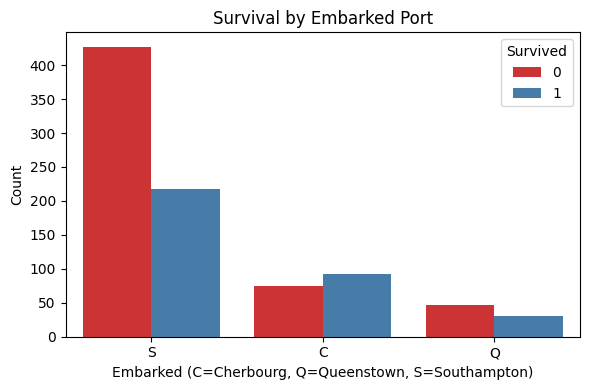

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Embarked', hue='Survived', data=df, palette='Set1')
plt.title('Survival by Embarked Port')
plt.xlabel('Embarked (C=Cherbourg, Q=Queenstown, S=Southampton)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

D**ata Processing and** **Cleaning**

In [ ]:
# These columns are not useful for prediction
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_clean = df.drop(columns=cols_to_drop)

print("Remaining columns:", df_clean.columns.tolist())

Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [ ]:
# Fill Age with median
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# Fill Embarked with mode (most frequent)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


/tmp/ipykernel_2991/3821662602.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
/tmp/ipykernel_2991/3821662602.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [ ]:
# Convert Sex to 0/1
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

# Convert Embarked to numbers
df_clean['Embarked'] = df_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("Encoding done!")
df_clean.head()

Encoding done!


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


Define Features & Target

In [ ]:
X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (891, 7)
Target shape: (891,)

Feature columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


Normalize Numearical Feature


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done! ✅")
print("Sample scaled values:\n", X_scaled[:3])

Scaling done! ✅
Sample scaled values:
 [[ 0.82737724 -0.73769513 -0.56573646  0.43279337 -0.47367361 -0.50244517
  -0.56883712]
 [-1.56610693  1.35557354  0.66386103  0.43279337 -0.47367361  0.78684529
   1.00518113]
 [ 0.82737724  1.35557354 -0.25833709 -0.4745452  -0.47367361 -0.48885426
  -0.56883712]]


Split into Train/Validation/Test Set

In [ ]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Second split: 50% validation, 50% test (from the 20% temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print("Training size  :", X_train.shape)
print("Validation size:", X_val.shape)
print("Testing size   :", X_test.shape)

Training size  : (712, 7)
Validation size: (89, 7)
Testing size   : (90, 7)


 **Train the Logistic Regression Model!**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully! ✅")

Model trained successfully! ✅


In [ ]:
#Make prediction

In [ ]:
# Predictions on test set
y_pred = model.predict(X_test)

# Probability scores
y_prob = model.predict_proba(X_test)[:, 1]

print("Sample Predictions (first 10):")
print("-" * 55)
print(f"{'Actual':<12} {'Predicted':<12} {'Probability':>10}")
print("-" * 55)
for i in range(10):
    print(f"{y_test.values[i]:<12} {y_pred[i]:<12} {y_prob[i]:>10.4f}")

Sample Predictions (first 10):
-------------------------------------------------------
Actual       Predicted    Probability
-------------------------------------------------------
0            1                0.7700
1            0                0.3072
0            1                0.6478
0            1                0.5986
0            1                0.7107
0            0                0.3399
1            1                0.7822
0            0                0.1065
0            0                0.3166
0            0                0.1378


**Evalution Metrics**

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_prob)

print("=" * 45)
print("   LOGISTIC REGRESSION - EVALUATION METRICS")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  AUC Score : {auc:.4f}")
print("=" * 45)

   LOGISTIC REGRESSION - EVALUATION METRICS
  Accuracy  : 0.7222  (72.22%)
  Precision : 0.6286
  Recall    : 0.6471
  F1 Score  : 0.6377
  AUC Score : 0.8193


Confusion Matrix

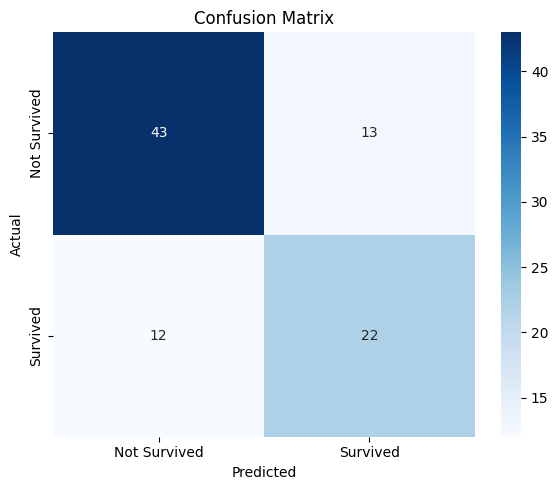

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

ROC Curve

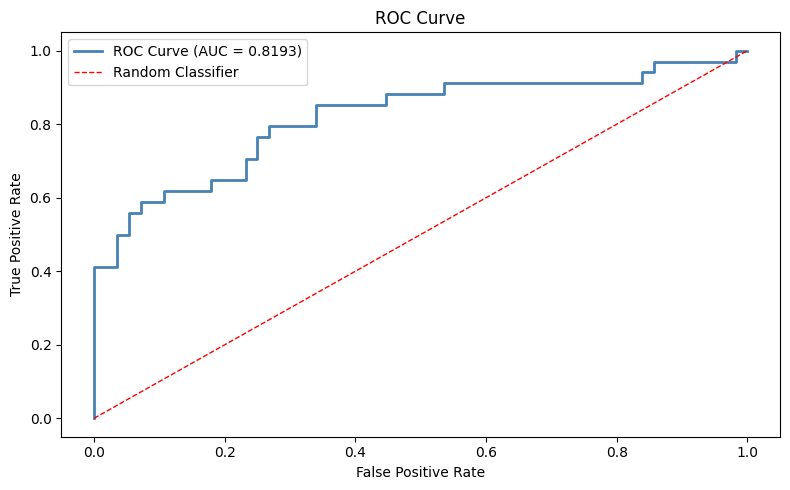

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--',
         linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

Validation Set Check

In [ ]:
y_val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("=" * 45)
print("   VALIDATION SET RESULTS")
print("=" * 45)
print(f"  Validation Accuracy : {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"  Test Accuracy       : {accuracy:.4f} ({accuracy*100:.2f}%)")
print("=" * 45)

   VALIDATION SET RESULTS
  Validation Accuracy : 0.8764 (87.64%)
  Test Accuracy       : 0.7222 (72.22%)
